# Krittika Summer Projects 7.0: Computational Astronomy Assignment: Gravitational Lensing

This assignment explores the phenomenon of **gravitational lensing** through a sequence of computational and conceptual exercises. You will gradually build a working model simulation, beginning with classical optics and extending to relativistic light deflection by massive objects.

## Structure of the Assignment

The assignment is divided into multiple parts, each building on the previous one:

- (a) Classical thin lens optics  
- (b) Gravitational lensing: theory and derivation  
- (c) Simulation of lensing for a single point source  
- (d) Extension to extended sources  
- (e) Formation of Einstein rings  
- (f) Inverse problem: reconstruction of the source (graphically)
- (g) BONUS: Reconstruction of the source (bitmap image)

Each section introduces new ideas while reinforcing earlier ones. You are encouraged to move sequentially, but partial completion is fully acceptable.

## Expectations and Evaluation

This assignment is designed to prioritise **understanding over completion**.

- Partial attempts will be **valued and credited**
- Clear reasoning and explanation of your approach are important
- It is acceptable if some parts of the code do not fully work, as long as your thought process is evident

You should aim to:
- Show intermediate steps
- Explain assumptions or approximations
- Identify where difficulties arise

Submissions will be evaluated not only on correctness, but also on **clarity of reasoning and effort**.

## Role of Visualisation

A central component of this assignment is the use of **visualisation to understand physical systems**. You will use the Python library Matplotlib for all plotting tasks.

Visualisation is an essential tool in computational physics and is widely used in research contexts, including Krittika Summer Projects (KSPs). Producing clear, accurate, and interpretable plots is a fundamental skill.


## Matplotlib Guidelines

All plots in this assignment must be created using Matplotlib (refer https://matplotlib.org/stable/users/index.html for more information). For clarity and consistency, use small marker sizes while plotting points so that structure is not obscured:

```python
plt.scatter(x, y, s=3.5)
```
---


## Part (a): Classical Thin Lens Optics

Before moving to gravitational lensing, we begin with a familiar system from geometrical optics: the **thin convex lens**. This serves as an important conceptual and mathematical analogue for understanding how light rays are deflected and how images are formed.

In this part, you will analyse how a point source is imaged by a thin lens using both analytical expressions and graphical construction.

### Physical Setup

- Consider a **thin convex lens** placed along the vertical line \( x = 0 \), extending from \( y = -1.5 \) to \( y = +1.5 \).
- The lens has a **focal length** \( f = 1 \) (in arbitrary units).
- A point source is located at coordinates \( (x_0, y_0) \).


#### (i) Analytical Image Formation

- Given a point \( (x_0, y_0) \) (take user input as a floating point), compute the image position \( (x', y') \)
- Carefully consider and handle all possible cases.


#### (ii) Ray Diagram Construction

You will then construct a **graphical ray diagram** using Matplotlib:

- Draw a **horizontal incident ray** from the point source to the lens
- Show how this ray is refracted by the lens


0.6666666666666667 0.16666666666666669


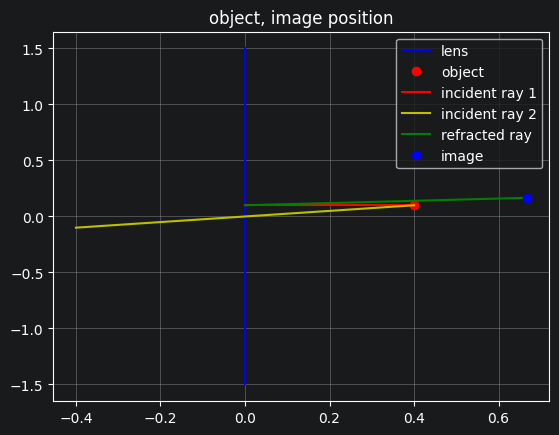

In [1]:
import numpy as np
import matplotlib.pyplot as plt
m = float('inf')
def position (pos, f):
    x, y = pos
    if (x> 0):
        f *= -1
    if (x == 0):
        return [x, y]
    if abs(abs(x) - abs(f)) <= 1e-10:
        return [m, m]
    x1 = (x*f)/(x+f)
    y1 = x1/x * y
    return [x1, y1]
f = 1
x, y = map(float, input().split())
x0 = [x, y]
x1, y1 = position(x0, f)
if (x1 == float('inf')):
    print('object at infinity')
else:
    print(x1, y1)
if (x1 == float('inf')):
    y1 = 0
    if (x > 0):
        x1 = -f
    else:
        x1 = +f
#ploting the graph
plt.plot([0, 0], [-1.5, 1.5], 'b-', label = 'lens')
plt.plot(x, y, 'ro', label = 'object')
plt.plot([0, x],[y, y] , 'r-', label = 'incident ray 1')
plt.plot([-x, x], [-y, y], 'y-', label = 'incident ray 2')


plt.plot([0, x1], [y, y1], 'g-', label = 'refracted ray')
if (abs(x1) != f):
    plt.plot(x1, y1, 'bo', label = 'image')
if (abs(x1) == f):
    plt.title('image at infinity')
else:
    plt.title('object, image position')
plt.grid()
plt.legend()
plt.show()




## Part (b): Gravitational Lensing — Theory

In this part, you will study how a massive object bends light and produces multiple images of a source.

![Gravitational Lensing Diagram](https://raw.githubusercontent.com/AT-2517/KSP7.0_Selection_Assignment/0b3c4e750f8e8473750b947bc84eb1a49259c091/Computational_Astronomy/Grav_Lensing_Diagram.png)

### Key Relations

Deflection angle:
$$
\tilde{\alpha} = \frac{4GM}{c^2 \xi}, \quad \xi = d_L \tan\theta
$$

Lens equation:
$$
\theta = \beta + \frac{d_{LS}}{d_S}\tilde{\alpha}
$$

Einstein angle:
$$
\theta_E = \sqrt{\frac{4GM}{c^2}\frac{d_{LS}}{d_L d_S}}
$$


### Task

- Solve the **exact equation** numerically  
- Find an approximate equation for situations $\theta_E$ is small. Solve the **approximate equation** analytically.
- Compute and plot the **percentage error** vs $\,\beta / \theta_E\,$  Identify the breakaway point where the error starts growing out of bounds.

Final equation-
$$\theta = \beta + \theta_E^2 / \tan{\theta}$$
if $\theta$ is small, we can say $\theta_E =  \beta + \theta_E^2 / \tan{\theta}$
hence $\theta = \frac{\beta \pm \sqrt{\beta^2 + 4 \theta^2}}{2}$

To solve this i use constants from part 3 and mass to be solar mass
I plot a graph between the solution $\theta$ and parameter $\beta$ in 1st 2 tasks

0.00010859355413651401


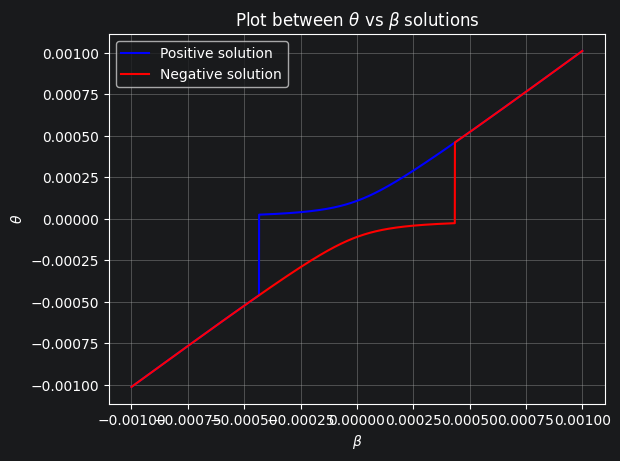

In [2]:
#finding solutions- task 1
from scipy.optimize import fsolve
dl = 5e11
ds = 9.75e17
dls = 9.75e17
G = 6.67e-11
M = 1.989e30 # solar mass
c = 3e8
B = np.linspace (-0.001, 0.001, 10001)
theta_E = np.sqrt( 4 * G * M /c**2 * dls/(dl*ds))
print(theta_E)
def f(x, b):
    return x- b - theta_E**2/np.tan(x)
r_plus = []
r_minus = []
for b in B:
    r = fsolve(f, - theta_E, args = (b,))[0]
    r_minus.append(r)
    r1 = fsolve(f, theta_E, args = (b,))[0]
    r_plus.append(r1)
# since theta_E is so small so graph between theta and b comes nearly to be straight line
plt.plot(B, r_plus, 'b-', label = 'Positive solution')
plt.plot(B, r_minus, 'r-', label = 'Negative solution')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\theta$')
plt.legend()
plt.title(r"Plot between $\theta$ vs $\beta$ solutions")
plt.grid()
plt.show()


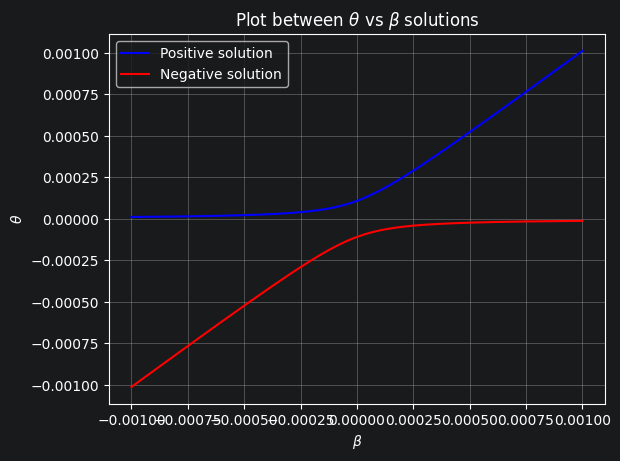

In [3]:
# part 2- approximate solution for small theta E
def f_minus(b, theta_e):
    return (b - np.sqrt(b**2 + 4* theta_e**2))/2
def f_plus(b, theta_e):
    return (b + np.sqrt(b**2 + 4* theta_e**2))/2
t_plus = f_plus(B, theta_E)
t_minus = f_minus(B, theta_E)
plt.plot(B, t_plus, 'b-', label = 'Positive solution')
plt.plot(B, t_minus, 'r-', label = 'Negative solution')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\theta$')
plt.legend()
plt.title(r"Plot between $\theta$ vs $\beta$ solutions")
plt.grid()
plt.show()



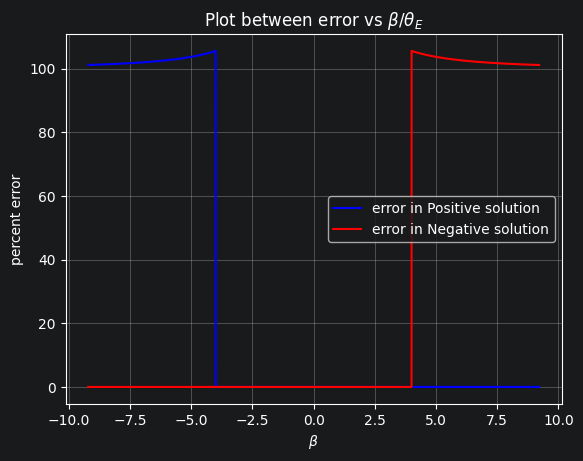

error burst in positive solution at -3.998395700854979
error burst in negative solution at 4.000237430795491


In [4]:
#part 3
# error in postive solutions-
err_plus = np.abs((t_plus - r_plus)/r_plus) * 100
err_minus = np.abs((t_minus - r_minus)/r_minus)* 100
plt.plot(B/theta_E, err_plus, 'b-', label = 'error in Positive solution')
plt.plot(B/theta_E, err_minus, 'r-', label = 'error in Negative solution')
plt.xlabel(r'$\beta$')
plt.ylabel(r'percent error')
plt.legend()
plt.title(r"Plot between error vs $\beta / \theta_E$")
plt.grid()
plt.show()

# finding the index at which diff is maximum
max_plus =0
max_minus = 0

max_ind_plus = 0
max_ind_minus = 0
for i in range (1, len(B)):
    if (np.abs(err_plus[i]- err_plus[i-1]) > max_plus):
        max_plus = np.abs(err_plus[i]- err_plus[i-1])
        max_ind_plus = i
    if (abs(err_minus[i]- err_minus[i-1]) > max_minus):
        max_minus = np.abs(err_minus[i]- err_minus[i-1])
        max_ind_minus = i
print("error burst in positive solution at", B[max_ind_plus]/theta_E)
print("error burst in negative solution at", B[max_ind_minus]/theta_E)


The error is bursts at $|\beta / \theta_E|$ = 4. We can see it graphically also by adjusting the plt.xlim

## Part (c): Simulation of a Single Lensed Point Source

In this part, you will simulate gravitational lensing of a **single point source** by a massive object placed at the origin.

Assume the following constants (fixed for the simulation):
$$
d_L = 5.00 \times 10^{11}\,\text{m}, \quad
d_S = 9.75 \times 10^{17}\,\text{m}, \quad
d_{LS} = 9.75 \times 10^{17}\,\text{m}
$$

Using these, compute the Einstein angle:
$$
\theta_E = \sqrt{\frac{4GM}{c^2} \cdot \frac{d_{LS}}{d_L d_S}}
$$

### Task

Given a source position $S = (x, y)$:
-Plot:
   - Source point
   - Image(s)
   - Lens at origin

### Cases to Explore

(i) Source on x/y axis (aligned cases)

(ii) Source off-axis (general cases)

---

In [5]:
# computing einstein angle
dl = 5e11
ds = 9.75e17
dls = 9.75e17
G = 6.67e-11
M = 1.989e30 # solar mass
c = 3e8
def einstein(dl, ds, dls):
    return np.sqrt(4*G*M/c**2 * dls/(dl*ds))
theta_E = einstein(dl, ds, dls)
print("einstein angle = " ,theta_E)



einstein angle =  0.00010859355413651401


I assume the x-y plane to be perpendicular to the line joining lens and observer and passing throught the source

In [27]:
x = 4e12
y = 5e13

def the_minus(b, theta_e):
    return (b - np.sqrt(b**2 + 4*theta_e**2))/2

def the_plus(b, theta_e):
    return (b + np.sqrt(b**2 + 4*theta_e**2))/2

def images_plot(x, y, title):
    r = np.sqrt(x**2 + y**2)
    b = np.arctan(r/ds)
    tm = the_minus(b, theta_E)
    tp = the_plus(b, theta_E)
    scale_factor_p = (ds*np.tan(tp))/r
    xp = x*scale_factor_p
    yp = y*scale_factor_p
    scale_factor_m = (ds*np.tan(tm))/r
    xm = x*scale_factor_m
    ym = y*scale_factor_m
    plt.scatter(0, 0, color='black', label='lens')
    plt.scatter(x, y, color='blue', label='source')
    plt.scatter(xm, ym, color='red', label='image outside einstein ring')
    plt.scatter(xp, yp, color='yellow', label='image inside einstein ring')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt.legend()
    plt.show()



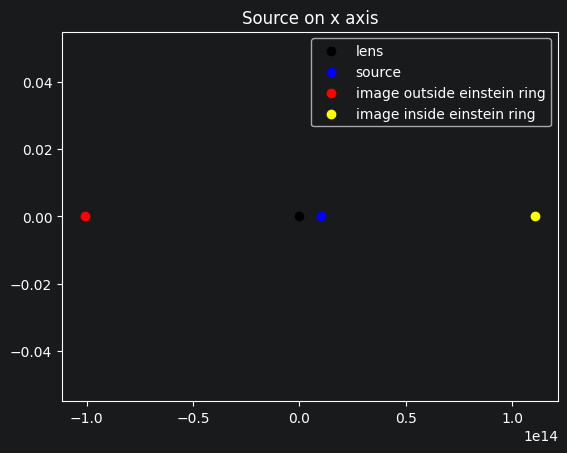

In [29]:
# xaxis-
x= 1e13
y = 0
title = 'Source on x axis'
images_plot(x, y , title)

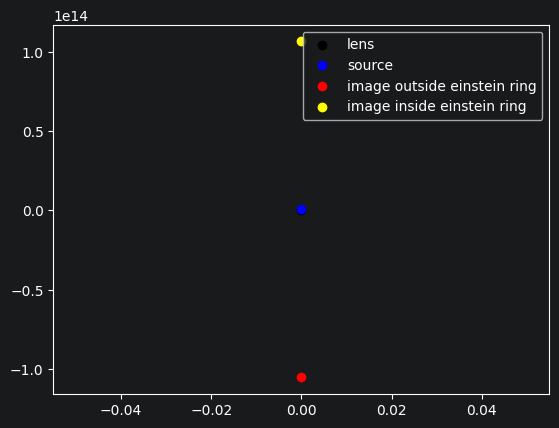

In [25]:
#y axis
x = 0
y = 1e12
t = 'Source on y axis'
images_plot(x, y, t)

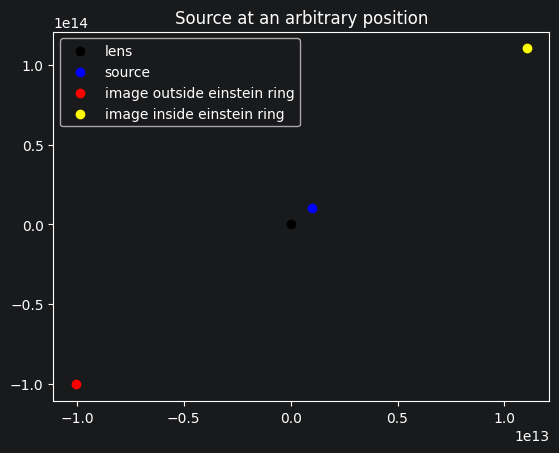

In [30]:
# arbitrary position
x = 1e12
y = 1e13
title = 'Source at an arbitrary position'
images_plot(x, y, title)

In [7]:
# computing the positions
def app_pos(x, y ,M = 1.989e30, G = 6.67e-11, dl = 5e11):
    dls = y
    ds = y+ dl
    e = einstein(dl, ds, dls)
    if (y == 0):
        b = np.pi/2
    else:
        b = np.arctan(x/ds)
    def f(x, b, theta_E):
        return x- b - theta_E**2/np.tan(x)
    tp = fsolve(f, np.abs(b)+e, args = (b, e))
    tm = fsolve(f, -np.abs(b)-e, args = (b, e))
    xp = y * np.tan(tp)
    xm = y * np.tan(tm)
    return xm , xp




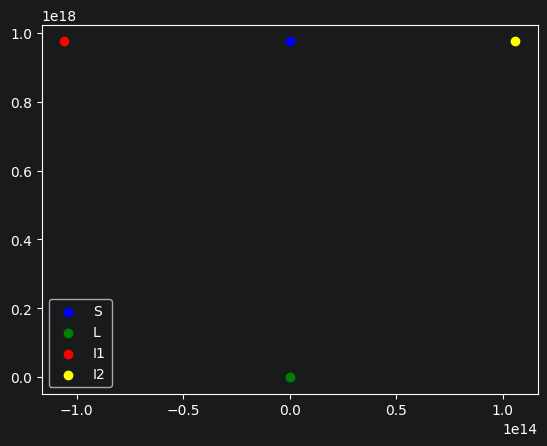

In [8]:
# y axis
x = 0
y = 9.75e17
xm, xp = app_pos(x, y)
plt.scatter(x, y, color = 'blue', label = 'S')
plt.scatter (0, 0, color = 'green', label = 'L')
plt.scatter (xm, y, color = 'red', label = 'I1')
plt.scatter(xp, y, color = 'yellow', label = 'I2')
plt.legend()
plt.show()

The case where we consider the source to be on x axis is extremely unphysical. All images coicides with L

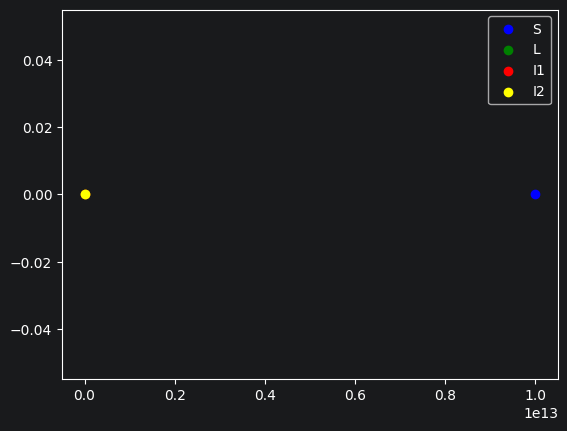

In [9]:
# X AXIS
x = 1e13
y = 0
xm, xp = app_pos(x, y)
plt.scatter(x, y, color = 'blue', label = 'S')
plt.scatter (0, 0, color = 'green', label = 'L')
plt.scatter (xm, y, color = 'red', label = 'I1')
plt.scatter(xp, y, color = 'yellow', label = 'I2')
plt.legend()
plt.show()

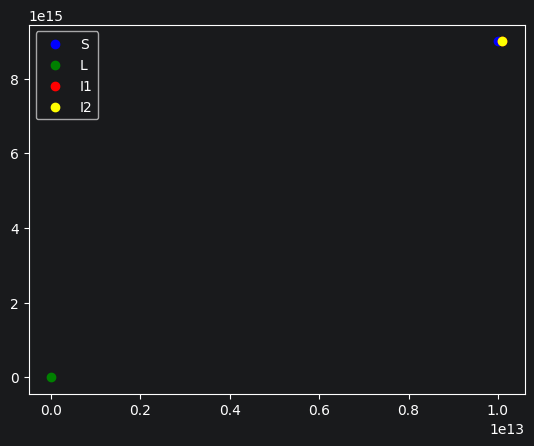

Source: 10000000000000.0 9000000000000000.0
Image+: [1.00940689e+13] 9000000000000000.0
Image-: [1.00940689e+13] 9000000000000000.0


In [10]:
# y axis
x = 1e13
y = 9e15
xm, xp = app_pos(x, y)
plt.scatter(x, y, color = 'blue', label = 'S')
plt.scatter (0, 0, color = 'green', label = 'L')
plt.scatter (xm, y, color = 'red', label = 'I1')
plt.scatter(xp, y, color = 'yellow', label = 'I2')
plt.legend()
plt.show()
print('Source:', x, y)
print('Image+:', xp, y)
print('Image-:', xm, y)

We may face issue using fsolve so we can also use the approximation we used earlier assumeing for small angles because in our fsolve we add an assumption. we me get wrong results due to it. The 3 cases are displayed down as shown for small angle approximation


In [11]:
# computing the positions
def app_pos_approx(x, y ,M = 1.989e30, G = 6.67e-11, dl = 5e11):
    dls = y
    ds = y+ dl
    e = einstein(dl, ds, dls)
    if (y == 0):
        b = np.pi/2
    else:
        b = np.arctan(x/ds)
    def f(x, b, theta_E):
            return x- b - theta_E**2/np.tan(x)
    def f_minus(b, theta_e):
        return (b - np.sqrt(b**2 + 4* theta_e**2))/2
    def f_plus(b, theta_e):
        return (b + np.sqrt(b**2 + 4* theta_e**2))/2
    theta_p = f_plus(b, e)
    theta_m = f_minus(b, e)
    xp = y * np.tan(theta_p)
    xm = y * np.tan(theta_m)
    return xm , xp




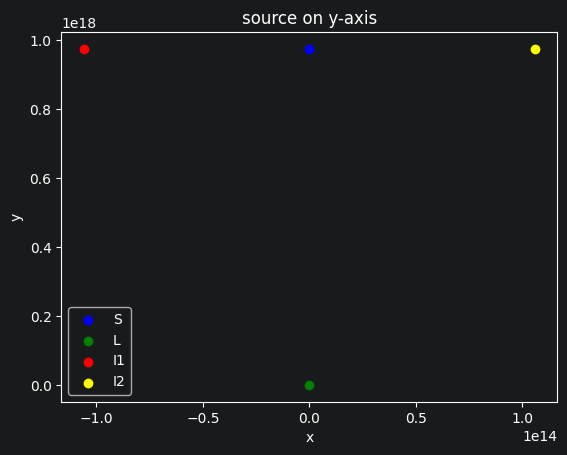

In [12]:
# y axis
x = 0
y = 9.75e17
xm, xp = app_pos_approx(x, y)
plt.scatter(x, y, color = 'blue', label = 'S')
plt.scatter (0, 0, color = 'green', label = 'L')
plt.scatter (xm, y, color = 'red', label = 'I1')
plt.scatter(xp, y, color = 'yellow', label = 'I2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('source on y-axis')
plt.legend()
plt.show()

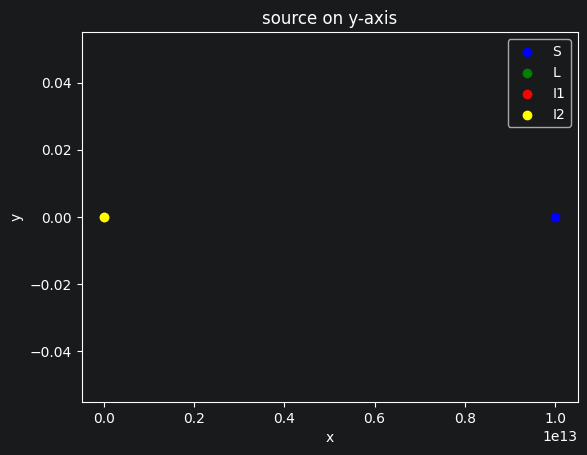

In [13]:
# X AXIS
x = 1e13
y = 0
xm, xp = app_pos_approx(x, y)
plt.scatter(x, y, color = 'blue', label = 'S')
plt.scatter (0, 0, color = 'green', label = 'L')
plt.scatter (xm, y, color = 'red', label = 'I1')
plt.scatter(xp, y, color = 'yellow', label = 'I2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('source on y-axis')
plt.legend()
plt.show()

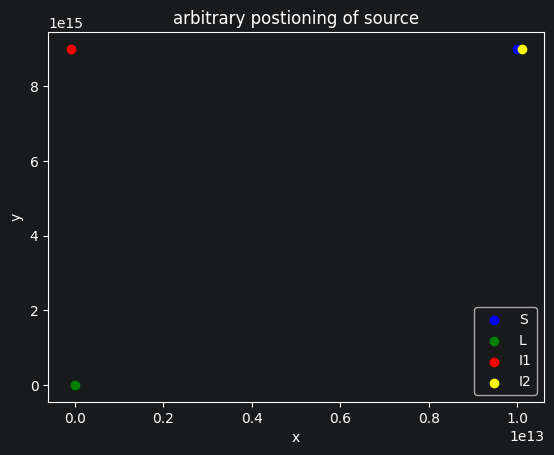

Source: 10000000000000.0 9000000000000000.0
Image+: 10094068941683.36 9000000000000000.0
Image-: -94624348463.88513 9000000000000000.0


In [14]:
# arbitrary
x = 1e13
y = 9e15
xm, xp = app_pos_approx(x, y)
plt.scatter(x, y, color = 'blue', label = 'S')
plt.scatter (0, 0, color = 'green', label = 'L')
plt.scatter (xm, y, color = 'red', label = 'I1')
plt.scatter(xp, y, color = 'yellow', label = 'I2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('arbitrary postioning of source')
plt.legend()
plt.show()
print('Source:', x, y)
print('Image+:', xp, y)
print('Image-:', xm, y)

Now onwards we will use the app_pos_approx function to estimate the postion of images

## Part (d): Extended Sources

In this part, you will extend your simulation from a single point source to an **extended source**, modelled as a collection of multiple points.

Assume the source is a small circular region centred at $(x_0, y_0)$ with radius $R$. This can be approximated by sampling many points within the circle.

### Task
Plot:
   - Original source points (blue, small markers)
   - Corresponding lensed image points (red/yellow)

### Suggested Parameters

- Number of points: 150–300

### Notes

- Use very small marker sizes ($s \leq 5$) for clarity
- You should observe distortion of the circular source near alignment
- You can plot both source points and image points on the same plane by considering angular variation only (i.e., plotting the points in terms of $\theta_x$ and $\theta_y$, where $\theta_x$, $\theta_y$ represent the angular separation from the source in the x and y directions).

---

In [ ]:
x0 = 1e13
y0 = 1e15
R = 1e12
N = 250
r_rand = R * np.sqrt(np.random.uniform(0, 1, N))  # sqrt for uniform distribution
theta_rand = np.random.uniform(0, 2*np.pi, N)
xo = x0 + r_rand * np.cos(theta_rand)
yo = y0 + r_rand * np.sin(theta_rand)
xi_p = []
xi_m = []


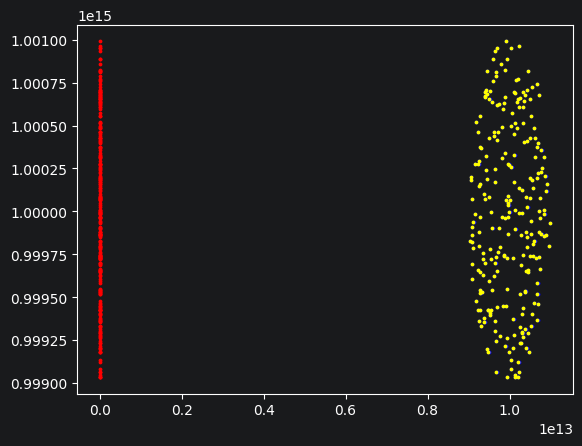

In [15]:
x0 = 1e13
y0 = 1e15
R = 1e12
N = 250
r_rand = R * np.sqrt(np.random.uniform(0, 1, N))  # sqrt for uniform distribution
theta_rand = np.random.uniform(0, 2*np.pi, N)
xo = x0 + r_rand * np.cos(theta_rand)
yo = y0 + r_rand * np.sin(theta_rand)
xi_p = []
xi_m = []
yi = []
for j in range(N):
    x = xo[j]
    y = yo[j]
    xm, xp = app_pos_approx(x, y)
    xi_p.append(xp)
    xi_m.append(xm)
plt.scatter (xo, yo, color = 'blue', s = 3 ,label = 'S')
plt.scatter(xi_p, yo, s=  3, color = 'yellow')
plt.scatter(xi_m, yo, s= 3, color = 'red')



In part d we kept the source far from lens so the object gets marked by images i.e not much distance between ine of the images from object
The red dots represents one of the images which almost looks like straight line but is a flattened circle if zoomed in
The yellow ones are just adjacent to the sources

## Part (e): Formation of an Einstein Ring

In this part, you will study how an **Einstein ring** forms as the source becomes increasingly aligned with the lens.

### Task

1. Consider a point source located along the vertical axis:
   $$
   S = (0, y)
   $$

2. Choose a sequence of source positions approaching perfect source-lens alignment along vertical axis.

3. Create **five separate plots**, one for each value of $y$:
   - Plot the source (blue)
   - Plot both image positions (red/yellow)
   - Plot the lens at the origin (black)

### Notes
- Ensure consistent axis limits across all plots for comparison  


In [16]:

#source positions
y_pos = [1e11, 1e8, 1e5, 1e3, 1e2]
x_pos= [0, 0, 0, 0, 0]
yi_pos = []
xi_pos_pos = []
xi_nig_pos = []
for j in range(5):
    x = x_pos[j]
    y = y_pos[j]
    xm, xp = app_pos_approx(x, y)
    xi_pos_pos.append(xp)
    xi_nig_pos.append(xm)
    yi_pos.append(y)


(-5000000.0, 5000000.0)

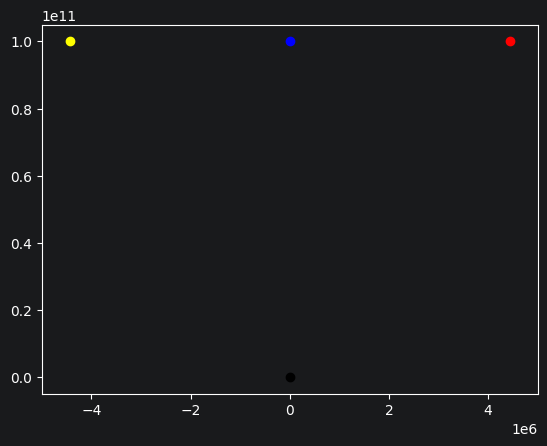

In [17]:
#plot 1
xo, yo = 0, y_pos[0]
xp, xm = xi_pos_pos[0], xi_nig_pos[0]
y = y_pos[0]
plt.scatter(xo, yo, color = 'blue', label = 'S')
plt.scatter(xp, y, color = 'red', label = 'I1')
plt.scatter(xm, y, color = 'yellow', label = 'I2')
plt.scatter(0, 0, color = 'black', label = 'L')
plt.xlim(-5e6, 5e6)

(-10000.0, 10000.0)

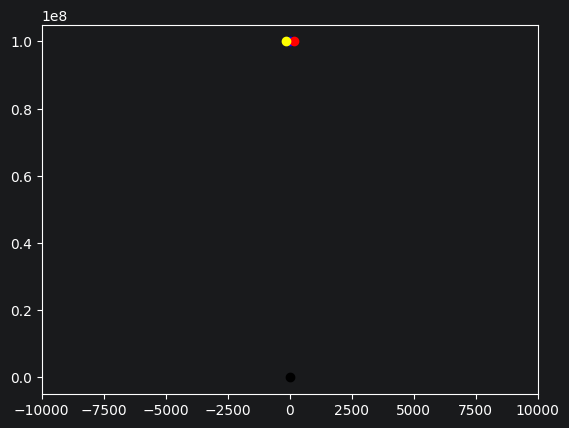

In [18]:
#plot 2
i = 1
xo, yo = 0, y_pos[i]
xp, xm = xi_pos_pos[i], xi_nig_pos[i]
y = y_pos[i]
plt.scatter(xo, yo, color = 'blue', label = 'S')
plt.scatter(xp, y, color = 'red', label = 'I1')
plt.scatter(xm, y, color = 'yellow', label = 'I2')
plt.scatter(0, 0, color = 'black', label = 'L')
plt.xlim(-1e4, 1e4)

(-50.0, 50.0)

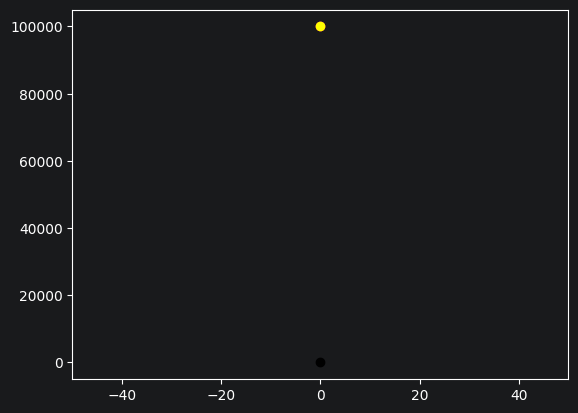

In [19]:
#plot 3
i = 2
xo, yo = 0, y_pos[i]
xp, xm = xi_pos_pos[i], xi_nig_pos[i]
y = y_pos[i]
plt.scatter(xo, yo, color = 'blue', label = 'S')
plt.scatter(xp, y, color = 'red', label = 'I1')
plt.scatter(xm, y, color = 'yellow', label = 'I2')
plt.scatter(0, 0, color = 'black', label = 'L')
plt.xlim(-5e1, 5e1)

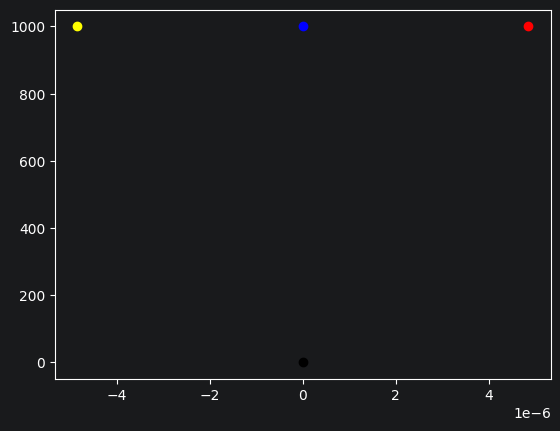

In [20]:
#plot 3
i = 3
xo, yo = 0, y_pos[i]
xp, xm = xi_pos_pos[i], xi_nig_pos[i]
y = y_pos[i]
plt.scatter(xo, yo, color = 'blue', label = 'S')
plt.scatter(xp, y, color = 'red', label = 'I1')
plt.scatter(xm, y, color = 'yellow', label = 'I2')
plt.scatter(0, 0, color = 'black', label = 'L')

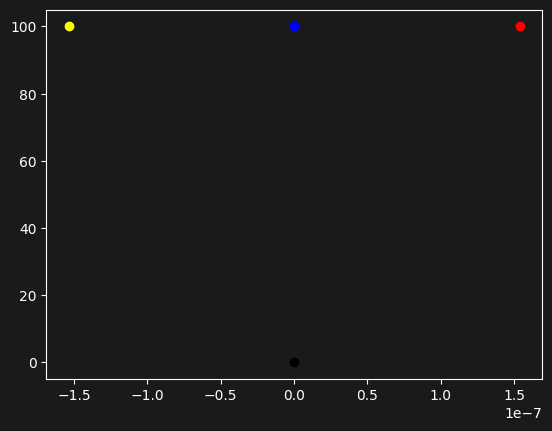

In [21]:
#plot 5
i = 4
xo, yo = 0, y_pos[i]
xp, xm = xi_pos_pos[i], xi_nig_pos[i]
y = y_pos[i]
plt.scatter(xo, yo, color = 'blue', label = 'S')
plt.scatter(xp, y, color = 'red', label = 'I1')
plt.scatter(xm, y, color = 'yellow', label = 'I2')
plt.scatter(0, 0, color = 'black', label = 'L')


we observe as we decrease the y distance the image and the object converges rapidly


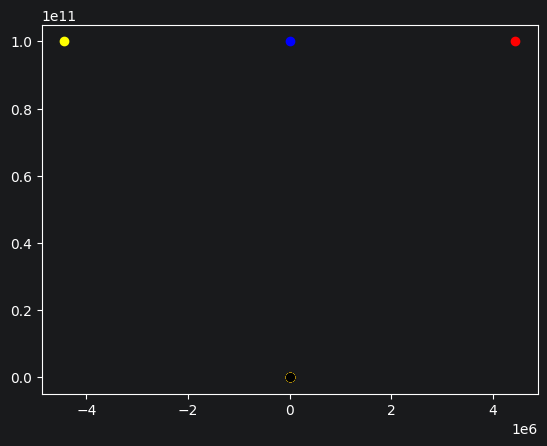

In [22]:
# combined plot
plt.scatter(x_pos, y_pos, color = 'blue', label = 'S')
plt.scatter(xi_pos_pos, y_pos, color = 'red', label = 'I1')
plt.scatter(xi_nig_pos, y_pos, color = 'yellow', label = 'I2')
plt.scatter(0, 0, color = 'black', label = 'L')

##Part (f): Original Image Reconstruction from Lensed Image

For this part, you are provided a set of points, that represents the lensed image of a celestial body. The coordinates of the lens are given to be (0, 0).
Use the provided [lensed_points.csv](https://github.com/krittikaiitb/KSP-7.0-Selection-Assignment/blob/master/Coding%20Assignment/lensed_points.csv)
###Task:

1. Derive the inverse transformation to find the set of coordinates corresponding to the original image.
2. Consider a celestial object represented by the set of coordinates in the .csv file. These represent the coordinates in the normalised angular space (i.e. in terms of $\theta_x/\theta_E$ and $\theta_y/\theta_E$).
3. Use the derived transformation to find the set of coordinates for the actual image. Plot it, using a suitable scale.

##Part (g): Bonus Question
You are provided with an actual 24-bit bitmap image ([hubble-lrg3757.bmp](https://github.com/krittikaiitb/KSP-7.0-Selection-Assignment/blob/master/Coding%20Assignment/hubble-lrg3757.bmp)) of a lensed galaxy, a nearly perfect Einstein Ring (Source: [NASA - LRG 3-757](https://science.nasa.gov/image-detail/einstein-ring-lrg-3-757/)). Use the transformation derived earlier and find the actual, de-lensed image of the galaxy (what the galaxy would look like if the original foreground cluster were not present).
![LRG 3-757](https://raw.githubusercontent.com/AT-2517/KSP7.0_Selection_Assignment/refs/heads/main/Computational_Astronomy/hubble-lrg3757.bmp)
###Task:
1. Import the image as a NumPy array. (Convert to Grayscale if necessary)
2. Write a script to map the pixels of the lensed image back to their source positions, You may have to crop the image suitably, use thresholding to identify bright regions of the image. You may refer to the OpenCV documentation here:- https://docs.opencv.org/4.x/index.html
3. Use $d_L$ = 6.3 $\times$ $10^9$ light years, $d_S$ = 10.9 $\times$ $10^9$ light years (refer to the diagram for the notation).

##